# Data Ingestion

This notebook demonstrates `portfolio.data.DataIngestion`, a thin wrapper around `yfinance.download` that pulls closing prices for every ticker declared in `portfolio.config` and produces clean, tidy DataFrames ready for the rest of the library.

We will:

1. Fetch prices for each asset class.
2. Run **exploratory data analysis (EDA)** on the resulting DataFrame — shape, missing values, summary statistics.
3. Visualise price levels and return distributions.
4. Show how `compute_returns` turns prices into returns.

## 1. Setup

`DataIngestion` takes optional `start_date` and `end_date` arguments; when omitted, it falls back to the values in `portfolio.config`.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from portfolio.data import DataIngestion

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ingestion = DataIngestion()
f"window: {ingestion.start_date} → {ingestion.end_date}"

'window: 2022-12-01 → 2026-04-30'

## 2. Fetching prices

Each `get_*_prices` method returns a DataFrame indexed by date with one column per ticker. Tickers are sorted alphabetically and rows containing NaN values are dropped.

In [2]:
stock_prices = ingestion.get_stock_prices()
stock_prices.tail()

[                       0%                       ]

[**                     4%                       ]  2 of 54 completed

[***                    6%                       ]  3 of 54 completed

[***                    7%                       ]  4 of 54 completed

[****                   9%                       ]  5 of 54 completed

...

[**********************94%********************   ]  51 of 54 completed

[**********************96%*********************  ]  52 of 54 completed

[**********************98%********************** ]  53 of 54 completed

[*********************100%***********************]  54 of 54 completed

Ticker,AAL,ABEV,AMD,AMZN,APLD,BB,BBD,BMNR,CCL,CIFR,...,SNAP,SOFI,STLA,T,TGT,TSLA,VG,VZ,WMT,WULF
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-31,10.74,2.92,203.429993,208.270004,23.740000,3.24,3.586255,19.780001,25.879999,12.87,...,4.60,15.880000,7.09,28.689732,121.199997,371.750000,15.76,49.456142,124.279999,14.43
2026-04-01,11.13,2.97,210.210007,210.570007,24.490000,3.36,3.664857,19.690001,26.580000,12.64,...,4.90,15.630000,7.43,28.016773,120.449997,381.260010,14.68,48.658142,124.739998,14.48
2026-04-02,10.84,2.93,217.500000,209.770004,24.559999,3.46,3.596080,19.450001,25.639999,12.82,...,4.63,15.850000,7.55,28.036568,120.449997,360.589996,14.64,48.667999,125.790001,14.88
2026-04-06,10.90,2.99,220.179993,212.789993,25.190001,3.55,3.659031,20.600000,25.969999,13.35,...,4.71,16.270000,7.48,28.026670,122.209999,352.820007,15.94,48.421703,126.790001,15.55
2026-04-07,10.81,2.97,221.529999,213.770004,25.180000,3.48,3.649195,20.170000,25.200001,14.01,...,4.80,16.110001,7.42,27.749571,119.519997,346.649994,15.99,47.899551,122.489998,16.57


## 3. EDA — shape, missingness, summary stats

Before modelling anything, it pays to confirm the data is what you expect. The four checks below catch the vast majority of ingestion-time problems (missing dates, dtype mismatches, constant columns, suspicious outliers).

In [3]:
print(f"shape:           {stock_prices.shape}")
print(f"date range:      {stock_prices.index.min().date()} → {stock_prices.index.max().date()}")
print(f"missing values:  {int(stock_prices.isna().sum().sum())}")
print(f"unique dtypes:   {stock_prices.dtypes.unique().tolist()}")

shape:           (210, 54)
date range:      2025-06-05 → 2026-04-07
missing values:  0
unique dtypes:   [dtype('float64')]


In [4]:
stock_prices.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAL,210.0,12.820429,1.542063,10.180000,11.580000,12.695000,13.757500,16.260000
ABEV,210.0,2.500254,0.286618,2.110000,2.276593,2.425066,2.642500,3.230000
AMD,210.0,194.182762,37.078446,115.690002,162.122498,202.375000,219.342495,264.329987
AMZN,210.0,224.034238,11.493341,198.789993,214.767502,223.639999,231.487503,254.000000
APLD,210.0,23.772286,8.921047,9.180000,14.910000,25.070000,30.987500,41.349998
BB,210.0,3.991143,0.451590,3.150000,3.660000,3.940000,4.320000,5.000000
BBD,210.0,3.301677,0.376540,2.693643,2.970847,3.284853,3.545164,4.112502
BMNR,210.0,35.586666,18.059265,4.263748,21.247500,32.885138,47.446064,134.960358
CCL,210.0,28.543476,2.576059,22.306887,26.171810,28.786932,30.576161,33.833607


## 4. Visualising price levels

Plotting raw price levels shows the rough scale and trend of each asset, but levels are not directly comparable across tickers (a stock at \$5 and one at \$500 say nothing about relative performance). Normalising every series to start at 1 makes the comparison fair.

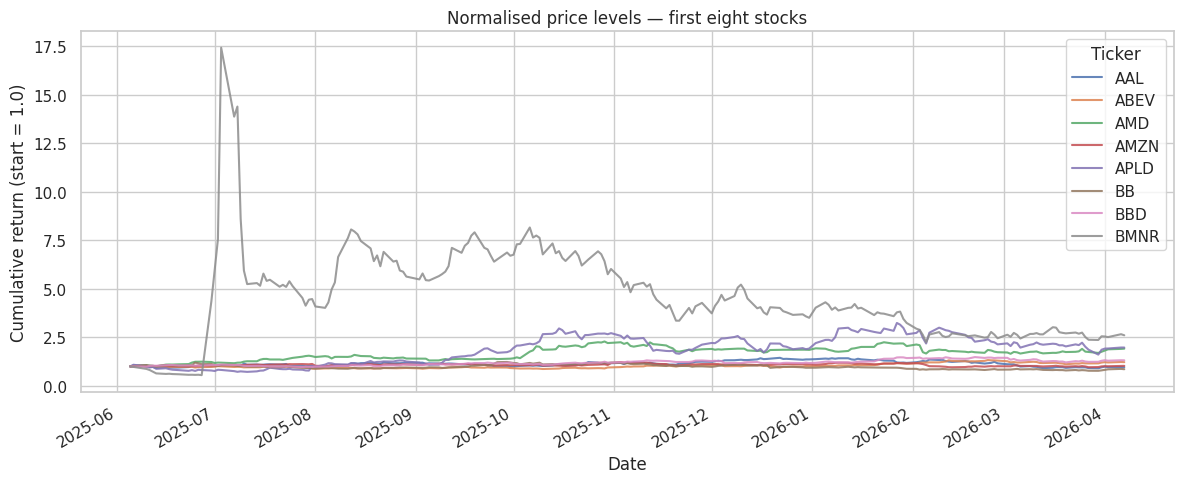

In [5]:
normalised = stock_prices / stock_prices.iloc[0]

fig, ax = plt.subplots()
normalised.iloc[:, :8].plot(ax=ax, alpha=0.85)
ax.set_title("Normalised price levels — first eight stocks")
ax.set_ylabel("Cumulative return (start = 1.0)")
ax.set_xlabel("Date")
fig.tight_layout()
plt.show()

## 5. Computing returns

`DataIngestion.compute_returns` applies `pct_change` and drops the leading NaN row. It is a static method, so you can pass it any price DataFrame — including one you loaded from disk.

In [6]:
stock_returns = DataIngestion.compute_returns(stock_prices)
stock_returns.tail()

Ticker,AAL,ABEV,AMD,AMZN,APLD,BB,BBD,BMNR,CCL,CIFR,...,SNAP,SOFI,STLA,T,TGT,TSLA,VG,VZ,WMT,WULF
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-31,0.055010,0.035461,0.037696,0.036427,0.155512,0.028571,0.042857,0.080874,0.080134,0.071161,...,0.144279,0.048185,0.050370,0.007297,0.020374,0.046358,-0.066903,-0.001988,0.006316,0.053285
2026-04-01,0.036313,0.017123,0.033328,0.011043,0.031592,0.037037,0.021918,-0.004550,0.027048,-0.017871,...,0.065217,-0.015743,0.047955,-0.023456,-0.006188,0.025582,-0.068528,-0.016136,0.003701,0.003465
2026-04-02,-0.026056,-0.013468,0.034680,-0.003799,0.002858,0.029762,-0.018767,-0.012189,-0.035365,0.014240,...,-0.055102,0.014076,0.016151,0.000707,0.000000,-0.054215,-0.002725,0.000203,0.008418,0.027624
2026-04-06,0.005535,0.020478,0.012322,0.014397,0.025652,0.026012,0.017505,0.059126,0.012871,0.041342,...,0.017279,0.026498,-0.009272,-0.000353,0.014612,-0.021548,0.088798,-0.005061,0.007950,0.045027
2026-04-07,-0.008257,-0.006689,0.006131,0.004606,-0.000397,-0.019718,-0.002688,-0.020874,-0.029650,0.049438,...,0.019108,-0.009834,-0.008021,-0.009887,-0.022011,-0.017488,0.003137,-0.010783,-0.033914,0.065595


### Distribution of daily returns

Daily returns are the input to every model in this repository. A quick histogram shows the central peak around zero and the fat tails that motivate VaR / CVaR.

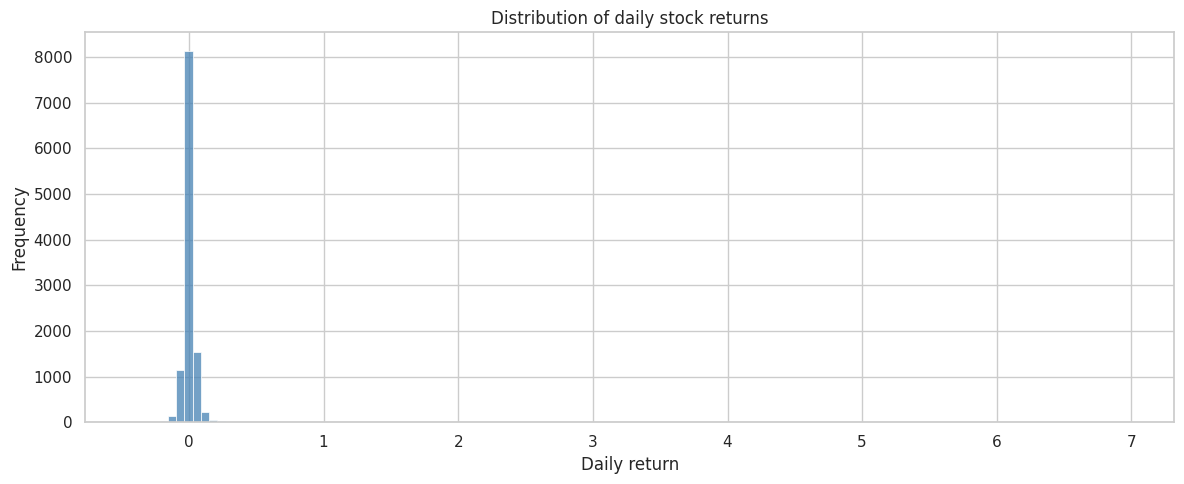

In [7]:
fig, ax = plt.subplots()
sns.histplot(stock_returns.stack(), bins=120, ax=ax, color="steelblue")
ax.set_title("Distribution of daily stock returns")
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
fig.tight_layout()
plt.show()

### Correlation structure

A correlation heatmap surfaces clusters of co-moving assets. These clusters matter for portfolio construction: the diversification benefit comes from combining assets with low (or negative) correlations.

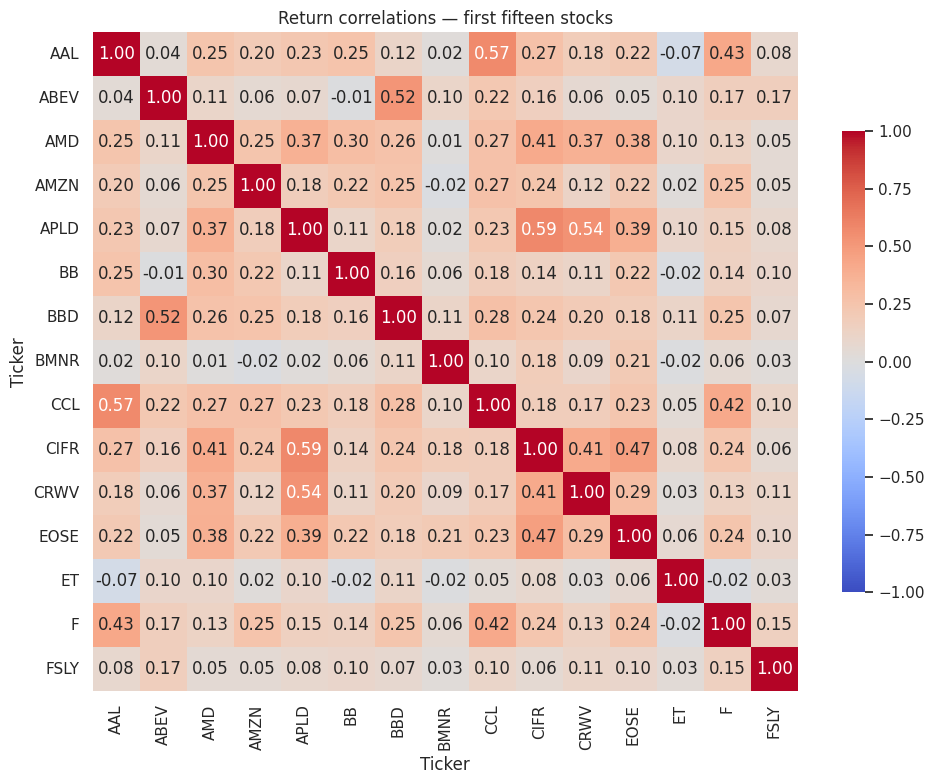

In [8]:
subset = stock_returns.iloc[:, :15]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    subset.corr(),
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    cbar_kws={"shrink": 0.7},
    ax=ax,
)
ax.set_title("Return correlations — first fifteen stocks")
fig.tight_layout()
plt.show()

## 6. Other asset classes

The remaining helpers (`get_etf_prices`, `get_bond_prices`, `get_crypto_prices`, `get_sp500_prices`) work the same way. `get_all_prices` returns the entire universe in one DataFrame.

In [9]:
ingestion.get_bond_prices().tail()

[                       0%                       ]

[**********************50%                       ]  2 of 4 completed

[**********************75%***********            ]  3 of 4 completed

[*********************100%***********************]  4 of 4 completed

Ticker,^FVX,^IRX,^TNX,^TYX
Date,,,,
2026-04-23,3.952,3.595,4.323,4.918
2026-04-24,3.920,3.593,4.310,4.916
2026-04-27,3.947,3.590,4.336,4.942
2026-04-28,3.983,3.590,4.354,4.944
2026-04-29,4.065,3.590,4.418,4.987


In [10]:
ingestion.get_crypto_prices().tail()

[                       0%                       ]

[****                   8%                       ]  2 of 26 completed

[******                12%                       ]  3 of 26 completed

[*******               15%                       ]  4 of 26 completed

[*********             19%                       ]  5 of 26 completed

...

[**********************85%****************       ]  22 of 26 completed

[**********************88%*****************      ]  23 of 26 completed

[**********************92%*******************    ]  24 of 26 completed

[*********************100%***********************]  26 of 26 completed

Ticker,ADA-USD,BNB-USD,BTC-USD,CBBTC32994-USD,DOGE-USD,ETH-USD,HYPE32196-USD,JU-USD,LINK-USD,MPRO31258-USD,...,TAO22974-USD,TRX-USD,UP39665-USD,USD136148-USD,USDC-USD,USDT-USD,USDT39520-USD,WETH-USD,XRP-USD,ZEC-USD
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-22,0.248560,637.931763,78203.101562,78516.937500,0.095738,2376.088135,41.190300,2.952769,9.298734,0.000406,...,246.014267,0.329701,0.200136,0.999944,0.999759,1.000192,1.001164,2387.791260,1.430028,317.116455
2026-04-23,0.250009,638.726257,78268.953125,78244.312500,0.097203,2331.513916,41.297943,2.927013,9.355892,0.000346,...,253.172058,0.328863,0.200023,1.000152,0.999998,1.000408,0.998895,2330.684814,1.439062,342.178009
2026-04-24,0.250448,636.402954,77455.312500,77445.421875,0.098456,2315.690186,41.144875,2.929904,9.377435,0.000348,...,248.505463,0.323644,0.199367,1.000014,0.999843,1.000242,1.000842,2315.575439,1.433676,359.690521
2026-04-25,0.250270,628.657288,77612.015625,77554.804688,0.098048,2318.829102,41.496044,3.031922,9.346175,0.000348,...,247.702240,0.324008,0.199332,0.999816,0.999733,1.000167,1.000012,2316.993896,1.424219,359.027161
2026-04-26,0.252328,636.111450,78657.539062,78649.031250,0.099289,2369.729004,42.543118,2.955179,9.494079,0.000348,...,251.673447,0.323531,0.198650,0.999989,0.999955,1.000292,1.000637,2368.157715,1.431575,355.121796


In [11]:
ingestion.get_all_prices().shape

[                       0%                       ]

[*                      2%                       ]  2 of 122 completed

[*                      2%                       ]  3 of 122 completed

[*                      2%                       ]  3 of 122 completed

[**                     4%                       ]  5 of 122 completed

...

[**********************98%********************** ]  119 of 122 completed

[**********************98%********************** ]  120 of 122 completed

[**********************99%***********************]  121 of 122 completed

[*********************100%***********************]  122 of 122 completed

(17, 122)